# Comparação de dados de treino vs. teste
Este notebook baixa a série de preços, aplica a mesma divisão treino/validação usada no projeto (split 80/20) e mostra estatísticas e gráficos para comparar as porções.
Se existir `models/model_config.json`, ele usa o `window_size` e o `ticker` salvos; caso contrário, usa valores padrão.

In [8]:
import json
from pathlib import Path

import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

# Parâmetros padrão
TICKER = 'PETR4.SA'
PERIOD = '5y'
INTERVAL = '1d'
TRAIN_SPLIT = 0.8
WINDOW_SIZE = 60

config_path = Path('models/model_config.json')
if config_path.exists():
    with config_path.open('r', encoding='utf-8') as f:
        cfg = json.load(f)
    TICKER = cfg.get('ticker', TICKER)
    WINDOW_SIZE = int(cfg.get('window_size', WINDOW_SIZE))
    print(f"Usando config salva: ticker={TICKER}, window_size={WINDOW_SIZE}")
else:
    print(f"Usando valores padrão: ticker={TICKER}, window_size={WINDOW_SIZE}")

Usando valores padrão: ticker=PETR4.SA, window_size=60


In [9]:
# Baixa e prepara dados
df = yf.download(TICKER, period=PERIOD, interval=INTERVAL, progress=False)
if df.empty:
    raise ValueError(f'Nenhum dado encontrado para {TICKER}.')

# Achata MultiIndex de colunas que o yfinance pode retornar
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Escolhe coluna de fechamento
if 'Close' in df.columns:
    close_col = 'Close'
elif 'Adj Close' in df.columns:
    close_col = 'Adj Close'
else:
    available = ', '.join(df.columns.tolist())
    raise ValueError(f"Coluna de fechamento n\u00e3o encontrada. Colunas dispon\u00edveis: {available}")

df = df[[close_col]].rename(columns={close_col: 'close'}).dropna()
print(f'Total de registros ap\u00f3s limpeza: {len(df)} (usando coluna {close_col})')
df.head()

Total de registros após limpeza: 1248 (usando coluna Close)


Price,close
Date,
2021-02-17,8.497479
2021-02-18,8.405583
2021-02-19,7.848465
2021-02-22,6.223062
2021-02-23,6.909408


In [10]:
# Divide em treino e teste respeitando ordem temporal
# .copy() evita SettingWithCopyWarning nas c\u00e9lulas seguintes
split_idx = int(len(df) * TRAIN_SPLIT)
if split_idx <= WINDOW_SIZE:
    raise ValueError('Poucos dados para a janela escolhida; aumente o per\u00edodo ou reduza window_size.')
df_train = df.iloc[:split_idx].copy()
df_test = df.iloc[split_idx:].copy()
print(f'Treino: {len(df_train)} pontos | Teste: {len(df_test)} pontos')

Treino: 998 pontos | Teste: 250 pontos


In [11]:
# Estat\u00edsticas descritivas por parte
train_desc = df_train['close'].describe().squeeze()
test_desc = df_test['close'].describe().squeeze()
summary = pd.concat([train_desc.rename('train'), test_desc.rename('test')], axis=1)
summary

,train,test
count,998.000000,250.000000
mean,18.661555,30.758707
std,8.845741,2.230712
min,6.059371,27.291746
25%,11.410740,29.289965
50%,15.685391,30.365416
75%,28.154256,31.349909
max,33.843620,38.080002


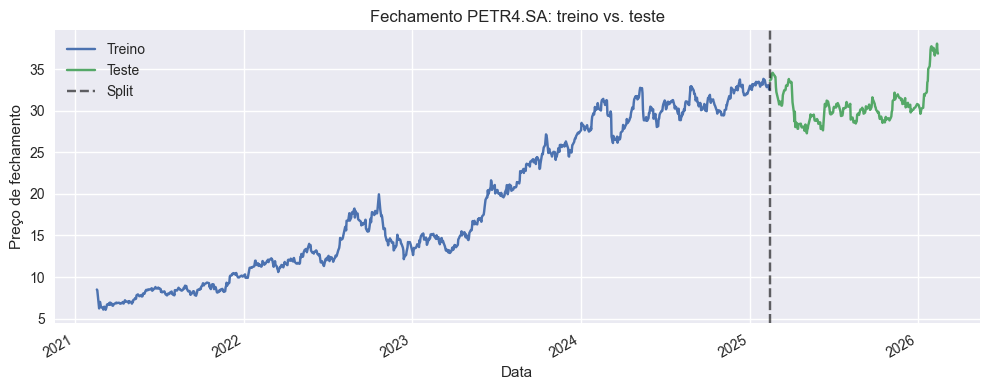

In [12]:
# Gráfico comparando as duas faixas no tempo
fig, ax = plt.subplots(figsize=(10, 4))
df_train['close'].plot(ax=ax, label='Treino')
df_test['close'].plot(ax=ax, label='Teste')
ax.axvline(df_test.index[0], color='k', linestyle='--', alpha=0.6, label='Split')
ax.set_title(f'Fechamento {TICKER}: treino vs. teste')
ax.set_xlabel('Data')
ax.set_ylabel('Preço de fechamento')
ax.legend()
plt.tight_layout()
plt.show()

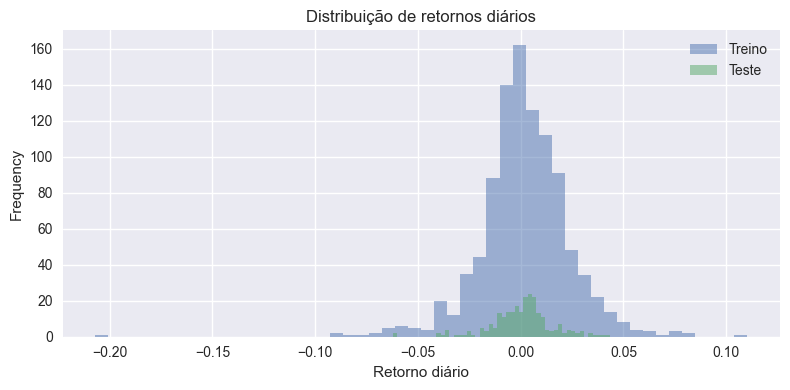

In [13]:
# Distribuição de retornos diários por parte
df_train['return'] = df_train['close'].pct_change()
df_test['return'] = df_test['close'].pct_change()
ax = df_train['return'].plot(kind='hist', bins=50, alpha=0.5, label='Treino', figsize=(8,4))
df_test['return'].plot(kind='hist', bins=50, alpha=0.5, label='Teste', ax=ax)
ax.set_title('Distribuição de retornos diários')
ax.set_xlabel('Retorno diário')
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# Checagem rápida de médias móveis em cada parte
for name, part in [('Treino', df_train), ('Teste', df_test)]:
    ma10 = part['close'].rolling(10).mean().iloc[-1]
    ma30 = part['close'].rolling(30).mean().iloc[-1]
    print(f"{name}: MA10={ma10:.2f}, MA30={ma30:.2f}")

Treino: MA10=33.12, MA30=33.16
Teste: MA10=37.27, MA30=34.37
